In [1]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260330_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='ic',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.75,
    gp_crossover_prob=0.7,
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=42,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

config_path: factors.genetic_programming@20260330_gp_test
selected_count: 1
selected_fc_name_list: ['fac_gp_0002']

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,-0.155923,-0.179698,0.163086,0.162987,-0.956079,-1.102531,-1.009872,-1.178703,0.192665,0.207855,...,"0.207855(0.15486,0.122289)","-0.956079(0.267796,-0.267796)","-1.10253(0.267796,-0.267796)","0.458678(0.516529,0.466942)","0.450413(0.516529,0.466942)","0.471725(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.157870,0.128391,0.163592,0.162300,0.965027,0.791072,1.204950,1.005210,0.101677,0.111686,...,"0.111686(0.146334,0.115003)","0.965027(-1.08921,1.08921)","0.791072(-1.08921,1.08921)","0.524793(0.483471,0.491736)","0.508264(0.483471,0.491736)","0.584913(0,0)",fac_gp_0049,1d,0.0002,C0
2024,0.044587,0.020223,0.148102,0.147986,0.301059,0.136658,0.456735,0.212340,0.081965,0.088683,...,"0.0886828(0.176943,0.0575955)","0.301059(-1.37663,1.37663)","0.136658(-1.37663,1.37663)","0.450413(0.417355,0.541322)","0.438017(0.417355,0.541322)","0.483409(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.036464,0.012106,0.154294,0.153996,0.236325,0.078614,0.258137,0.087470,0.204988,0.221220,...,"0.22122(0.30725,0.362493)","0.236325(0.176769,-0.176769)","0.0786136(0.176421,-0.177116)","0.493399(0.495875,0.480198)","0.482673(0.495875,0.480198)","0.483281(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.056390,0.001731,0.106543,0.106926,0.529270,0.016189,0.673673,0.021077,0.075642,0.094074,...,"0.0940741(0.0487138,0.291679)","0.52927(2.75956,-2.75956)","0.0161889(2.75777,-2.76134)","0.460905(0.563786,0.411523)","0.427984(0.563786,0.411523)","1.0845(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.086856,0.032736,0.141937,0.141912,0.611936,0.230678,0.700840,0.270076,0.135780,0.142338,...,"0.142338(0.148106,0.111244)","0.611936(0.0391665,-0.0391665)","0.230678(0.0391665,-0.0391665)","0.526749(0.497942,0.489712)","0.485597(0.497942,0.489712)","1.07382(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.014499,-0.045345,0.108764,0.109034,0.133307,-0.415881,0.170470,-0.536464,0.079788,0.111697,...,"0.111697(0.15486,0.122289)","0.133307(0.267796,-0.267796)","-0.415881(0.267796,-0.267796)","0.508264(0.516529,0.466942)","0.466942(0.516529,0.466942)","1.18738(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.139840,0.086771,0.116071,0.115543,1.204776,0.750981,1.479501,0.947156,0.047028,0.051178,...,"0.0511776(0.146334,0.115003)","1.20478(-1.08921,1.08921)","0.750981(-1.08921,1.08921)","0.520661(0.483471,0.491736)","0.483471(0.483471,0.491736)","1.05296(0,0)",fac_gp_0050,1d,0.0002,C0
2024,0.009766,-0.047481,0.117612,0.117909,0.083031,-0.402689,0.094714,-0.466512,0.085213,0.099588,...,"0.0995883(0.176943,0.0575955)","0.0830312(-1.37663,1.37663)","-0.402689(-1.37663,1.37663)","0.438017(0.417355,0.541322)","0.438017(0.417355,0.541322)","1.13584(0,0)",fac_gp_0050,1d,0.0002,C0


In [2]:
# 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
1


In [3]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0002     True
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [4]:
print(check2)

Factor Name
fac_gp_0002     True
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [5]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0042    1.149768
fac_gp_0006    1.036989
fac_gp_0011    1.016011
fac_gp_0012    1.016011
fac_gp_0013    1.016011
fac_gp_0001    0.979790
fac_gp_0002    0.943086
fac_gp_0009    0.916922
fac_gp_0004    0.891529
fac_gp_0005    0.856717
fac_gp_0022    0.854619
fac_gp_0010    0.810446
fac_gp_0007    0.805313
fac_gp_0008    0.805313
fac_gp_0018    0.690022
fac_gp_0038    0.676434
fac_gp_0024    0.643064
fac_gp_0023    0.643064
fac_gp_0017    0.626023
fac_gp_0037    0.615065
fac_gp_0034    0.603203
fac_gp_0036    0.601383
fac_gp_0003    0.591901
fac_gp_0047    0.511886
fac_gp_0021    0.510915
fac_gp_0020    0.510915
fac_gp_0019    0.510915
fac_gp_0045    0.467158
fac_gp_0025    0.426335
fac_gp_0048    0.397486
fac_gp_0044    0.372255
fac_gp_0043    0.372255
fac_gp_0016    0.361131
fac_gp_0015    0.361131
fac_gp_0014    0.361131
fac_gp_0026    0.351982
fac_gp_0040    0.340999
fac_gp_0041    0.340999
fac_gp_0039    0.320522
fac_gp_0027    0.270485
fac_gp_0035    0.265463
fac_

In [6]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0002    0.149290
fac_gp_0011    0.144882
fac_gp_0013    0.144882
fac_gp_0012    0.144882
fac_gp_0006    0.144697
fac_gp_0009    0.139287
fac_gp_0005    0.123091
fac_gp_0022    0.116751
fac_gp_0004    0.112600
fac_gp_0010    0.102516
fac_gp_0001    0.095899
fac_gp_0038    0.090272
fac_gp_0008    0.086943
fac_gp_0007    0.086943
fac_gp_0034    0.083004
fac_gp_0036    0.082772
fac_gp_0018    0.076286
fac_gp_0019    0.075812
fac_gp_0020    0.075812
fac_gp_0021    0.075812
fac_gp_0023    0.073265
fac_gp_0024    0.073265
fac_gp_0037    0.072923
fac_gp_0003    0.069495
fac_gp_0047    0.064218
fac_gp_0017    0.060615
fac_gp_0026    0.050938
fac_gp_0025    0.050585
fac_gp_0046    0.047054
fac_gp_0040    0.044784
fac_gp_0041    0.044784
fac_gp_0014    0.040072
fac_gp_0016    0.040072
fac_gp_0015    0.040072
fac_gp_0027    0.039205
fac_gp_0043    0.038206
fac_gp_0044    0.038206
fac_gp_0039    0.036515
fac_gp_0048    0.034141
fac_gp_0045    0.033134
fac_gp_0035    0.032172
fac_

In [7]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0001    0.088352
fac_gp_0009    0.078381
fac_gp_0013    0.076159
fac_gp_0011    0.076159
fac_gp_0012    0.076159
fac_gp_0006    0.074349
fac_gp_0002    0.071911
fac_gp_0005    0.070554
fac_gp_0034    0.068891
fac_gp_0004    0.065890
fac_gp_0003    0.064812
fac_gp_0008    0.061806
fac_gp_0007    0.061806
fac_gp_0010    0.060713
fac_gp_0022    0.060451
fac_gp_0042    0.056079
fac_gp_0038    0.055935
fac_gp_0023    0.054902
fac_gp_0024    0.054902
fac_gp_0018    0.054885
fac_gp_0027    0.053618
fac_gp_0037    0.051255
fac_gp_0047    0.049611
fac_gp_0036    0.048015
fac_gp_0017    0.045543
fac_gp_0025    0.044374
fac_gp_0021    0.043592
fac_gp_0020    0.043592
fac_gp_0019    0.043592
fac_gp_0044    0.038572
fac_gp_0043    0.038572
fac_gp_0026    0.035022
fac_gp_0035    0.034545
fac_gp_0014    0.034451
fac_gp_0015    0.034451
fac_gp_0016    0.034451
fac_gp_0048    0.032987
fac_gp_0050    0.031635
fac_gp_0032    0.030946
fac_gp_0033    0.030946
fac_gp_0029    0.030946
fac_

In [8]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 Neg(TsBeta(low, TsMin(TsMin(close, 10), 20), 10))
fac_gp_0002 TsBeta(TsDecayExp(high, 5), TsDecayExp(low, 5), 10)
fac_gp_0003 Neg(TsBeta(TsDecayExp(high, 5), TsMin(TsMin(close, 10), 20), 10))
fac_gp_0004 Neg(TsBeta(low, TsDecayExp(high, 5), 10))
fac_gp_0005 Neg(TsBeta(TsDecayExp(low, 5), TsDecayExp(high, 5), 10))
fac_gp_0006 TsBeta(open, low, 10)
fac_gp_0007 RangePosition(low, 5)
fac_gp_0008 Abs(RangePosition(low, 5))
fac_gp_0009 Neg(TsBeta(TsDecayExp(TypicalPrice(high), 5), TsDecayExp(high, 5), 10))
fac_gp_0010 Neg(TsBeta(TypicalPrice(low), TsDecayExp(high, 5), 10))
fac_gp_0011 TsBeta(open, TypicalPrice(close), 10)
fac_gp_0012 TsBeta(open, TypicalPrice(open), 10)
fac_gp_0013 TsBeta(open, Abs(TypicalPrice(high)), 10)
fac_gp_0014 Neg(Div(volume, RangePosition(TypicalPrice(low), 5)))
fac_gp_0015 Neg(Div(volume, RangePosition(TypicalPrice(high), 5)))
fac_gp_0016 Neg(Div(volume, RangePosition(TypicalPrice(open), 5)))
fac_gp_0017 Lt(close, TsDecayExp(high, 5))
fac_gp_0018 RangeP

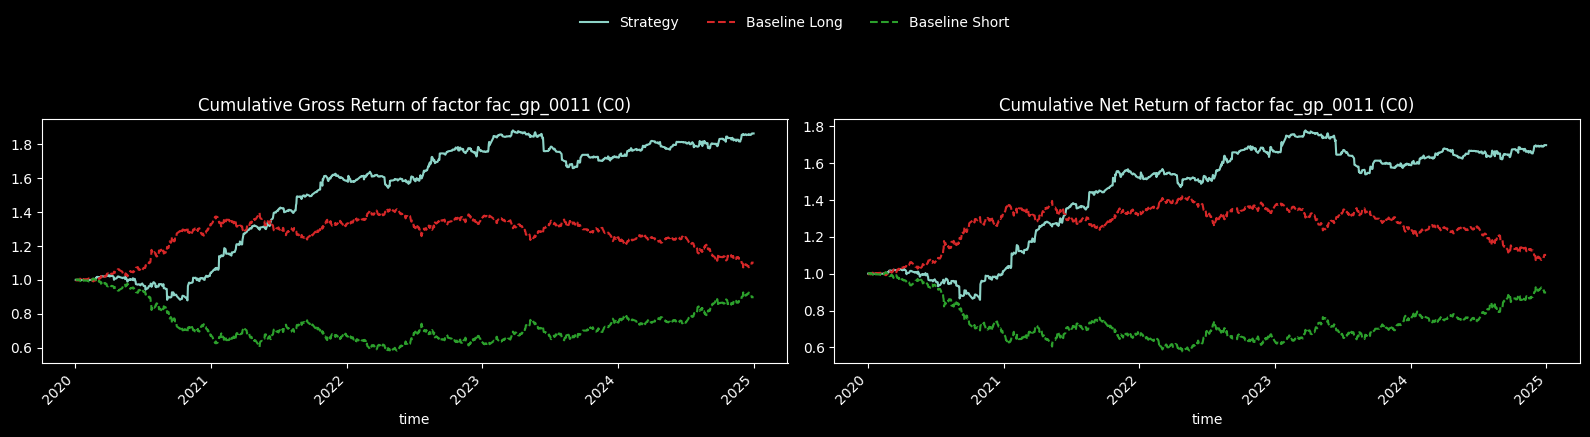

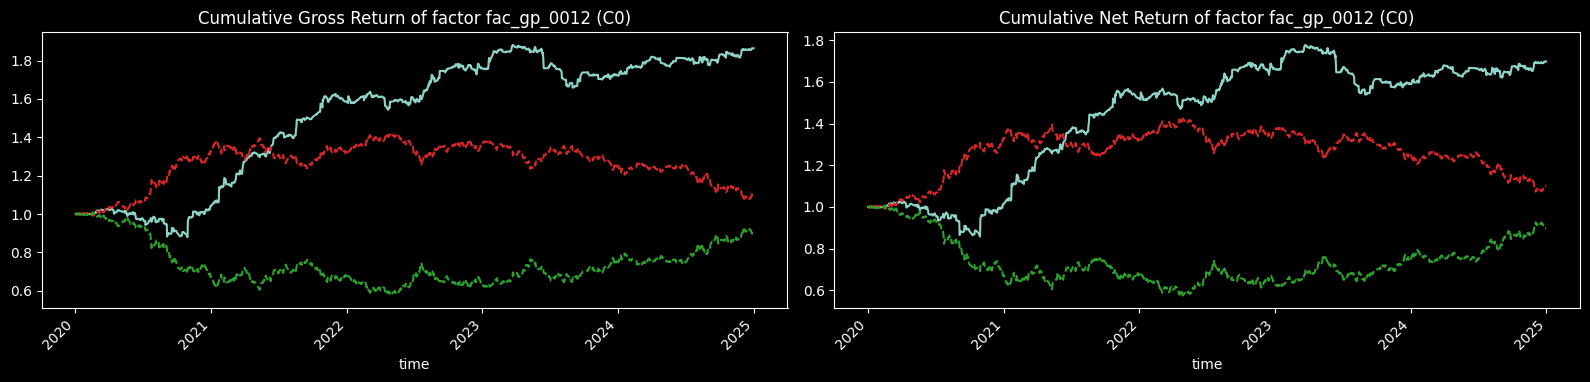

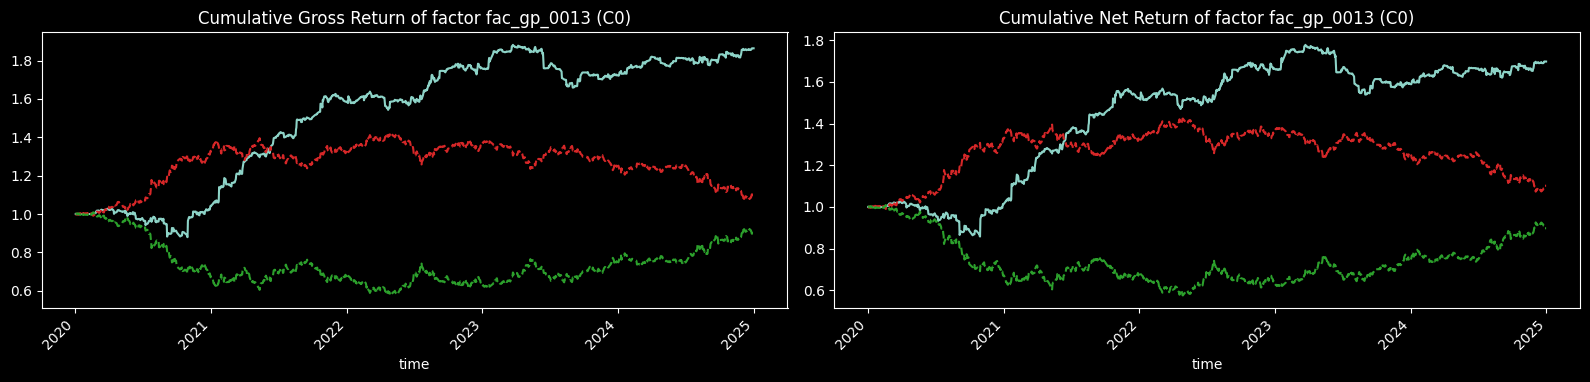

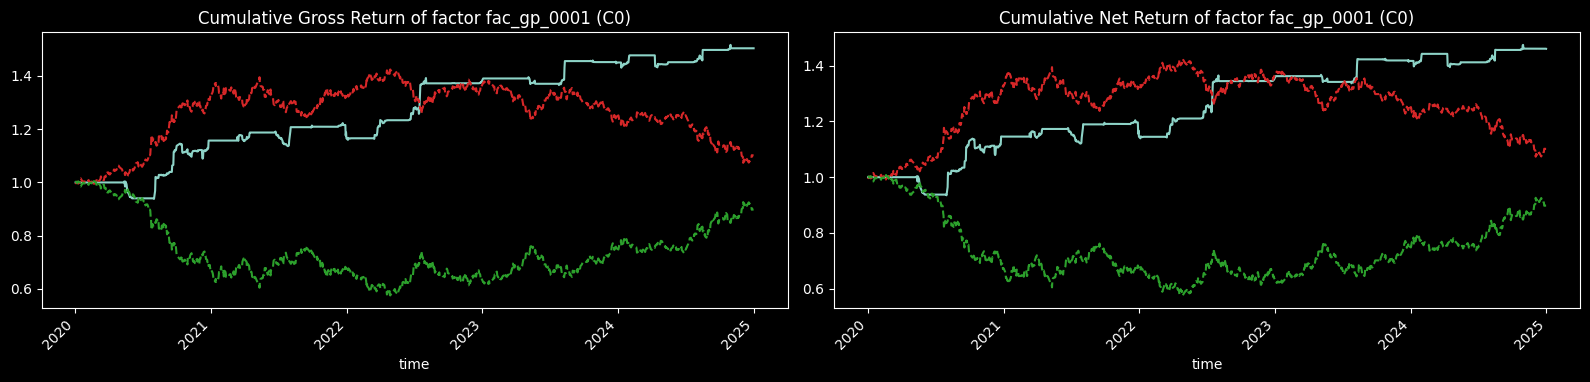

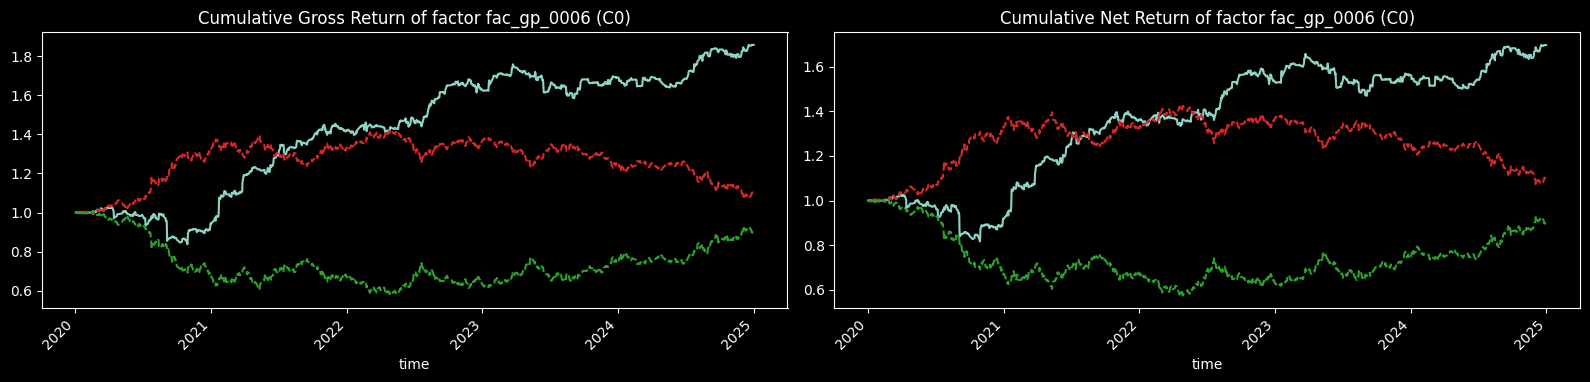

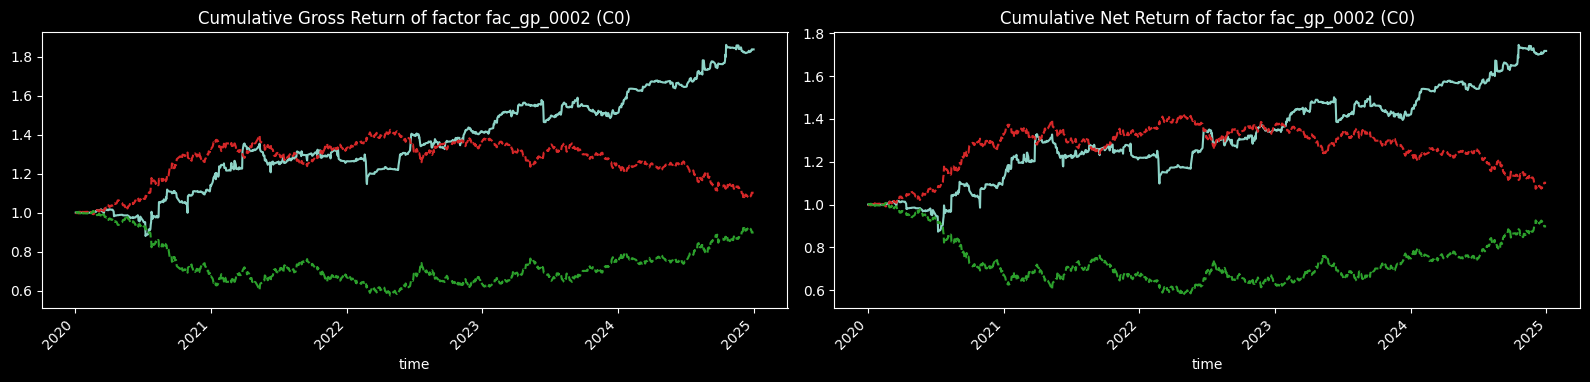

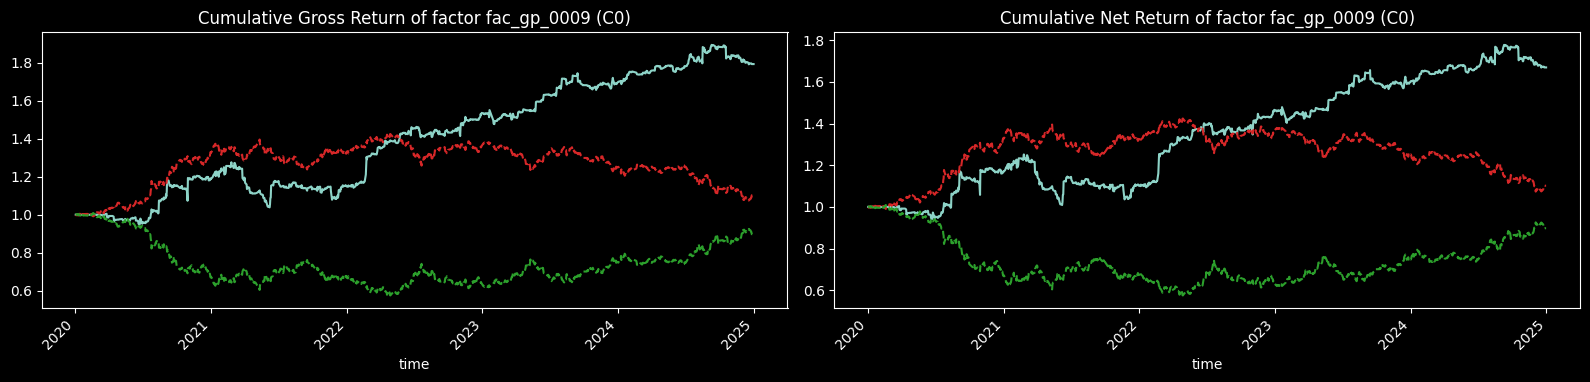

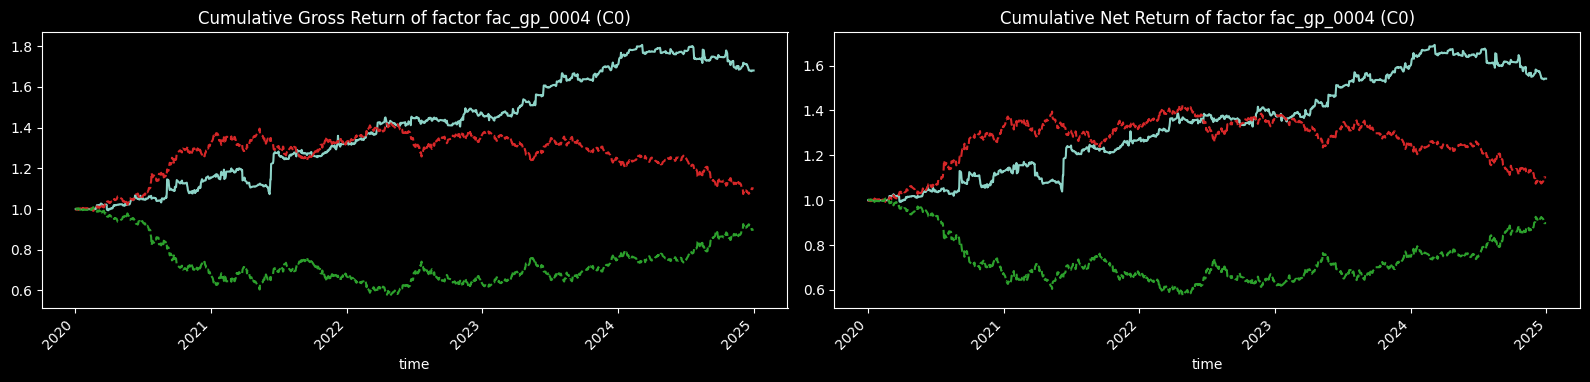

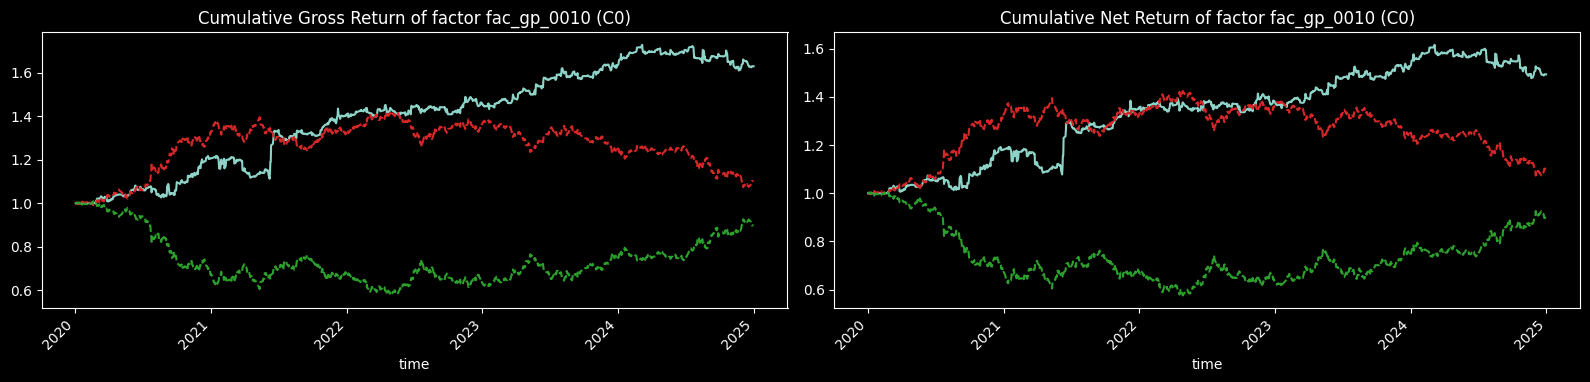

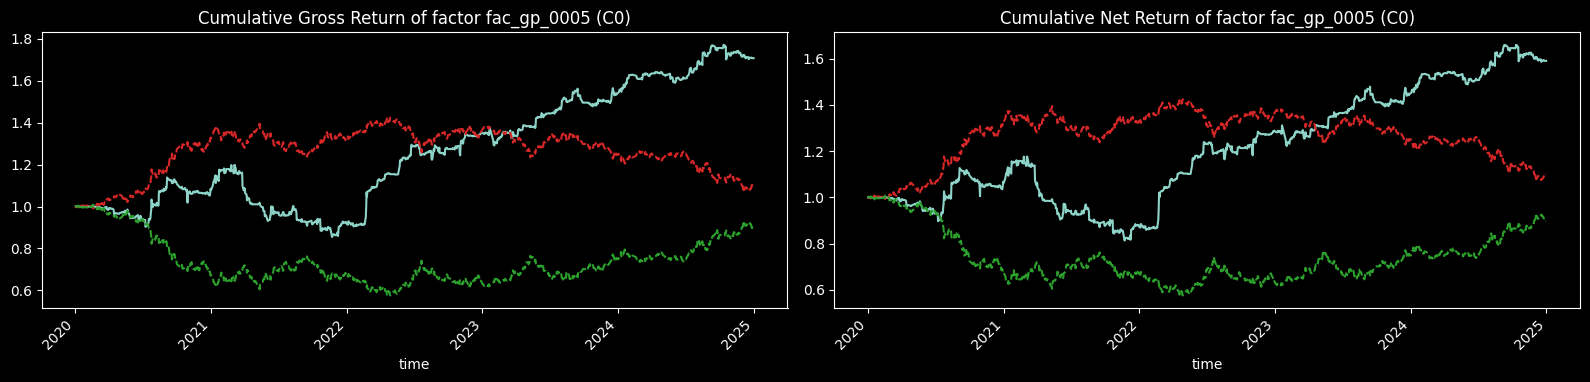

In [9]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

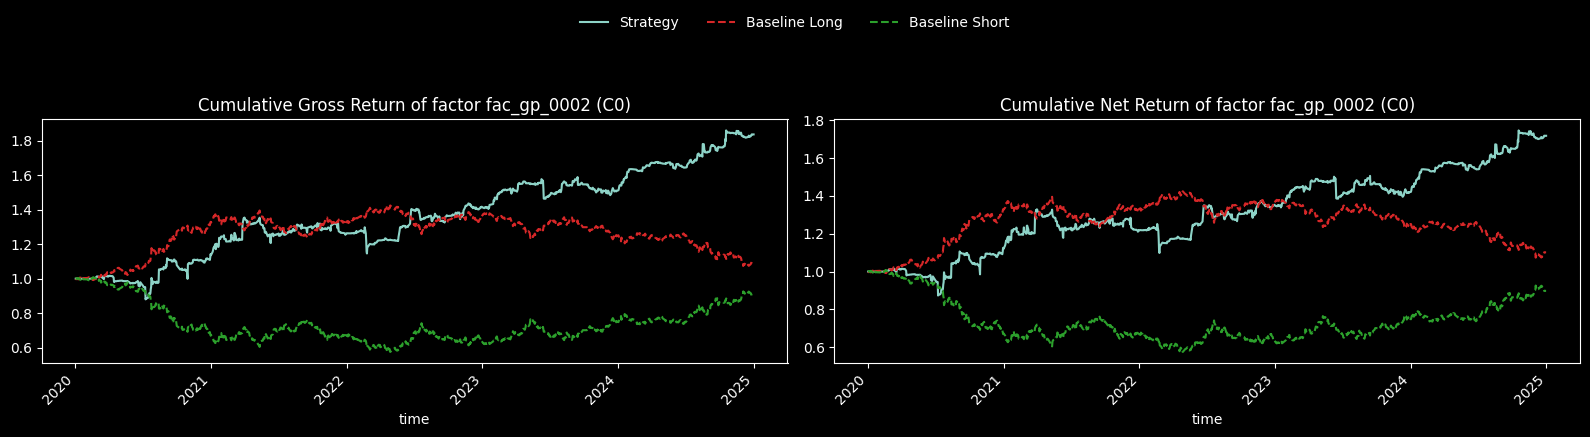

In [11]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=True)